# 2.9 — Associative Search (Contextual Bandits)

---

## Adding a state, but not a consequence

So far the task has been **nonassociative**: there was one situation, and the best action
was a fixed thing to be discovered. Real reinforcement learning has more than one
situation, and the best action *depends on which one you are in*.

The **associative search** task (elsewhere: **contextual bandit**) sits exactly between:

| | multiple situations? | actions affect the *next* situation? |
|---|---|---|
| $k$-armed bandit | no | no |
| **associative search** | **yes** | **no** |
| full RL problem | yes | yes |

You are shown a context $S_t$, choose $A_t$, and get $R_t$ depending on both. The next
context arrives independently of what you did. So you must learn a **policy** — a mapping
from situations to actions — but you never have to reason about *delayed* consequences.

$$\pi: \mathcal{S} \to \mathcal{A} \qquad\text{instead of}\qquad a^* \in \mathcal{A}$$

The book's example: at each step, one of several slot machines is chosen at random and
identified to you by the colour of its display. Learn the colour→lever policy.

## Why this middle step matters

The moment actions influence the next state, you get the **full** RL problem and need
everything from Chapter 3 onward — returns, value functions, the Bellman equations.
Associative search shows you exactly which part of the difficulty comes from *context*
(not much — it is basically $k$ separate bandits) and which comes from *delayed
consequences* (almost all of it).

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
from bandit_utils import (Testbed, run_bandit, plot_pair, argmax_random_tiebreak,
                          hide, banner, RUNS, STEPS)

plt.rcParams["figure.dpi"] = 110
banner()

mode=FULL  runs=2000  steps=1000
switch with:  import os; os.environ['RL_MODE']='FULL'  (before importing)


In [2]:
class EpsGreedy:
    def __init__(self, k, runs, rng, eps=0.1, Q_init=0.0, alpha=None):
        self.k, self.runs, self.rng, self.eps = k, runs, rng, eps
        self.alpha = alpha
        self.Q = np.full((runs, k), float(Q_init))
        self.N = np.zeros((runs, k))

    def act(self):
        greedy = argmax_random_tiebreak(self.Q, self.rng)
        rand = self.rng.integers(0, self.k, size=self.runs)
        explore = self.rng.random(self.runs) < self.eps
        return np.where(explore, rand, greedy)

    def update(self, a, r):
        idx = np.arange(self.runs)
        self.N[idx, a] += 1
        step = self.alpha if self.alpha else 1.0 / self.N[idx, a]
        self.Q[idx, a] += step * (r - self.Q[idx, a])


class UCB:
    def __init__(self, k, runs, rng, c=2.0, alpha=None):
        self.k, self.runs, self.rng, self.c, self.alpha = k, runs, rng, c, alpha
        self.Q = np.zeros((runs, k)); self.N = np.zeros((runs, k)); self.t = 0

    def act(self):
        self.t += 1
        with np.errstate(divide="ignore", invalid="ignore"):
            bonus = self.c * np.sqrt(np.log(self.t) / self.N)
        bonus[self.N == 0] = np.inf
        return argmax_random_tiebreak(self.Q + bonus, self.rng)

    def update(self, a, r):
        idx = np.arange(self.runs)
        self.N[idx, a] += 1
        step = self.alpha if self.alpha else 1.0 / self.N[idx, a]
        self.Q[idx, a] += step * (r - self.Q[idx, a])


class GradientBandit:
    def __init__(self, k, runs, rng, alpha=0.1, baseline=True):
        self.k, self.runs, self.rng = k, runs, rng
        self.alpha, self.use_baseline = alpha, baseline
        self.H = np.zeros((runs, k)); self.Rbar = np.zeros(runs); self.t = 0
        self.pi = np.full((runs, k), 1.0 / k)

    def act(self):
        e = np.exp(self.H - self.H.max(axis=1, keepdims=True))
        self.pi = e / e.sum(axis=1, keepdims=True)
        u = self.rng.random((self.runs, 1))
        return (self.pi.cumsum(axis=1) < u).sum(axis=1)

    def update(self, a, r):
        self.t += 1
        base = self.Rbar if self.use_baseline else 0.0
        oh = np.zeros_like(self.H); oh[np.arange(self.runs), a] = 1.0
        self.H += self.alpha * (r - base)[:, None] * (oh - self.pi)
        if self.use_baseline:
            self.Rbar += (r - self.Rbar) / self.t


def eps_agent(eps, Q_init=0.0, alpha=None):
    return lambda k, runs, rng: EpsGreedy(k, runs, rng, eps=eps, Q_init=Q_init, alpha=alpha)

def ucb_agent(c, alpha=None):
    return lambda k, runs, rng: UCB(k, runs, rng, c=c, alpha=alpha)

def grad_agent(alpha, baseline=True):
    return lambda k, runs, rng: GradientBandit(k, runs, rng, alpha=alpha, baseline=baseline)

print("agents defined")

agents defined


## The simplest version: independent bandits per context

If the contexts are fully observable and discrete, an associative task with $|S|$
contexts is *literally* $|S|$ independent bandit problems interleaved at random. Just
keep a separate $Q(s, a)$ table.

In [3]:
class ContextualBandit:
    def __init__(self, n_states=3, k=10, runs=500, seed=0):
        rng = np.random.default_rng(seed)
        self.n_states, self.k, self.runs = n_states, k, runs
        self.rng = rng
        self.q = rng.normal(0, 1, size=(runs, n_states, k))

    def observe(self):
        self.s = self.rng.integers(0, self.n_states, size=self.runs)
        return self.s

    def step(self, a):
        idx = np.arange(self.runs)
        return self.rng.normal(self.q[idx, self.s, a], 1.0)

    def optimal(self):
        idx = np.arange(self.runs)
        return self.q[idx, self.s].argmax(axis=1)


def run_contextual(n_states=3, eps=0.1, steps=2000, runs=500, k=10,
                   contextual=True, seed=0):
    env = ContextualBandit(n_states, k, runs, seed)
    rng = np.random.default_rng(seed + 1)
    Q = np.zeros((runs, n_states if contextual else 1, k))
    N = np.zeros_like(Q)
    idx = np.arange(runs)
    rew = np.zeros(steps); opt = np.zeros(steps)
    for t in range(steps):
        s = env.observe()
        srow = s if contextual else np.zeros(runs, int)
        Qs = Q[idx, srow]
        greedy = argmax_random_tiebreak(Qs, rng)
        a = np.where(rng.random(runs) < eps, rng.integers(0, k, runs), greedy)
        best = env.optimal()
        r = env.step(a)
        N[idx, srow, a] += 1
        Q[idx, srow, a] += (r - Q[idx, srow, a]) / N[idx, srow, a]
        rew[t] = r.mean(); opt[t] = (a == best).mean() * 100
    return {"rewards": rew, "optimal": opt}

print("contextual runner defined")

contextual runner defined


---

### Predict first

We will run a 3-context, 10-arm associative task two ways:

- **context-aware:** a separate $Q(s,a)$ table per context;
- **context-blind:** a single $Q(a)$ table, ignoring the colour of the machine.

1. Where will the context-blind agent's % optimal curve plateau? Above or below 33%?
2. The context-aware agent has 3× as many parameters to learn. Will it be *slower* to
   get going?
3. What if there were 50 contexts instead of 3?

*Write your guess down (mentally or in the cell below) before running the next cell. The point is not to be right — it is to make the surprise informative when you are wrong.*

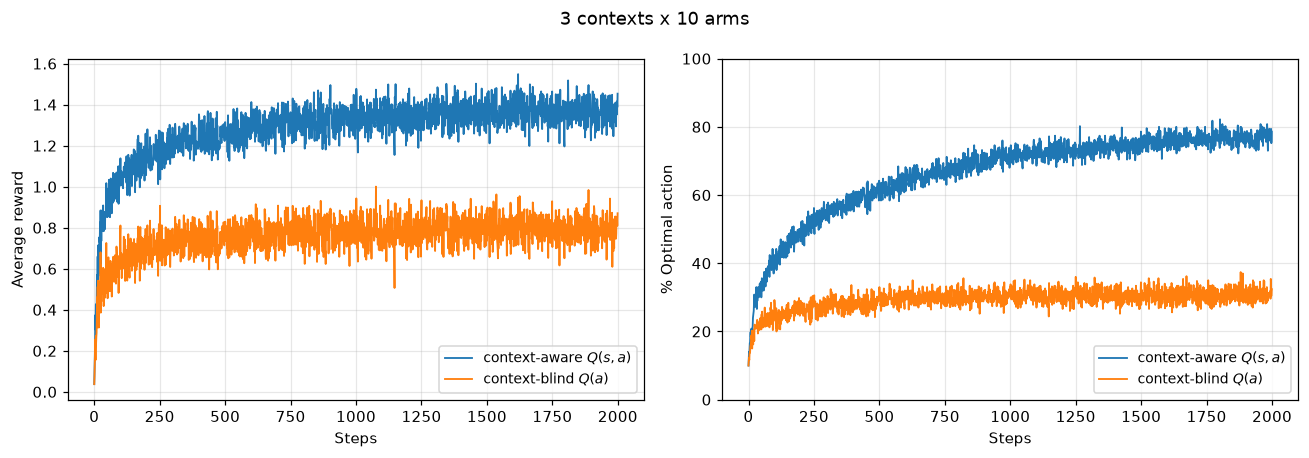

aware    %opt last 200 =  76.9  reward last 200 = 1.366
blind    %opt last 200 =  30.9  reward last 200 = 0.794


In [4]:
aware = run_contextual(n_states=3, contextual=True, seed=4)
blind = run_contextual(n_states=3, contextual=False, seed=4)

plot_pair([aware, blind], ["context-aware $Q(s,a)$", "context-blind $Q(a)$"],
          title="3 contexts x 10 arms")
plt.show()

for lab, r in [("aware", aware), ("blind", blind)]:
    print(f"{lab:<8} %opt last 200 = {r['optimal'][-200:].mean():5.1f}  "
          f"reward last 200 = {r['rewards'][-200:].mean():.3f}")

In [5]:
hide('''<b>1.</b> The blind agent converges on the single arm with the best <i>average</i>
value across contexts, then picks it always. Because the three contexts&#39; q* tables are
drawn independently, that arm is optimal in about one context out of three &mdash; so
% optimal plateaus near <b>31%</b>, essentially the 1/3 you would guess. (Had the contexts
been correlated, it would land higher; the independence is what pins it to 1/n.) Its
reward is permanently and substantially below the aware agent&#39;s.
<br><br><b>2.</b> Yes &mdash; the aware agent sees each (state, action) pair only 1/3 as
often, so its early curve rises more slowly. It still overtakes quickly here, but the
crossover is real: <b>with a short enough horizon, ignoring the context is the right
call</b>. That is the bias-variance trade-off of state representation, met for the first
time.
<br><br><b>3.</b> With 50 contexts the aware agent needs 50&times;10 = 500 estimates from
the same data budget. Below some horizon it would lose outright. The fix is
<i>generalisation</i> &mdash; sharing statistical strength across similar contexts, i.e.
function approximation, Part II of the book.''')

## The horizon crossover, directly

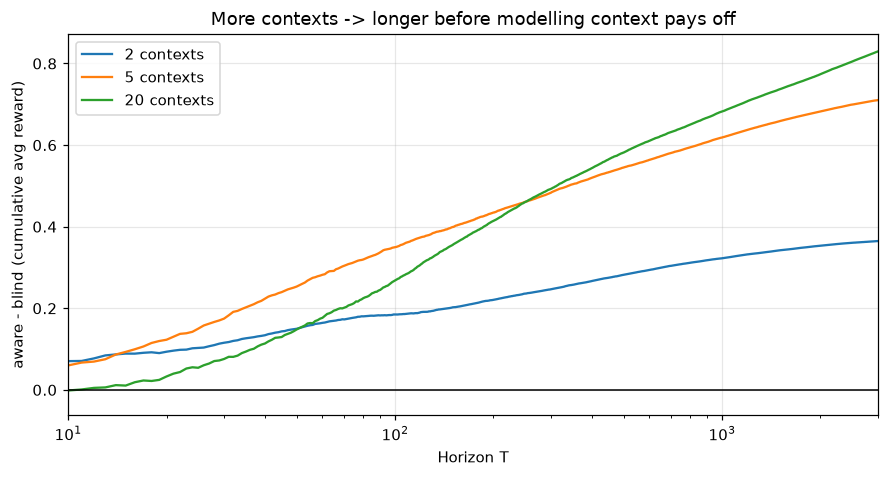

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
for n_states in [2, 5, 20]:
    a = run_contextual(n_states=n_states, contextual=True, steps=3000, runs=300, seed=6)
    b = run_contextual(n_states=n_states, contextual=False, steps=3000, runs=300, seed=6)
    diff = np.cumsum(a["rewards"] - b["rewards"]) / np.arange(1, 3001)
    ax.plot(diff, label=f"{n_states} contexts")
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("Horizon T"); ax.set_ylabel("aware - blind (cumulative avg reward)")
ax.set_title("More contexts -> longer before modelling context pays off")
ax.legend(); ax.grid(alpha=0.3); ax.set_xscale("log"); ax.set_xlim(10, 3000)
plt.show()

Every curve starts **negative** — early on, splitting your data by context is a net loss —
and crosses zero later the more contexts there are. This single plot contains the entire
argument for why representation matters in RL.

## Exercise 2.10 — two cases, with and without knowing which

> Suppose you face a 2-armed bandit task whose true values change randomly from time step
> to time step. Specifically, with probability 0.5 you face case A, where action 1 gives a
> reward of 0.1 and action 2 gives 0.2; with probability 0.5 you face case B, where action
> 1 gives 0.9 and action 2 gives 0.8. (a) If you are not able to tell which case you face,
> what is the best expectation of success you can achieve, and how should you behave to
> achieve it? (b) Now suppose you *can* tell which case you face. What is the best
> expected reward then, and how should you behave?

**(a) Without context.** Marginal values:

$$\mathbb{E}[R \mid \text{action } 1] = 0.5(0.1) + 0.5(0.9) = 0.5, \qquad
\mathbb{E}[R \mid \text{action } 2] = 0.5(0.2) + 0.5(0.8) = 0.5$$

The two actions are **indistinguishable in expectation**. Best achievable is $0.5$, by
any policy whatsoever. This is a nonassociative task with no signal at all.

**(b) With context.** Now play the best action in each case: action 2 in case A ($0.2$),
action 1 in case B ($0.9$):

$$0.5(0.2) + 0.5(0.9) = \boxed{0.55}$$

The gap $0.55 - 0.50 = 0.05$ is **the value of the context information** — what it is
worth to see the colour of the machine. Verify:

In [7]:
rew = {"A": [0.1, 0.2], "B": [0.9, 0.8]}
rng = np.random.default_rng(0)
T = 200000
cases = rng.integers(0, 2, size=T)

policies = {
    "always action 1":        lambda c: np.zeros(T, int),
    "always action 2":        lambda c: np.ones(T, int),
    "random 50/50":           lambda c: rng.integers(0, 2, size=T),
    "context-aware optimal":  lambda c: np.where(c == 0, 1, 0),
    "context-aware WORST":    lambda c: np.where(c == 0, 0, 1),
}
table = np.array([[0.1, 0.2], [0.9, 0.8]])
for name, pol in policies.items():
    a = pol(cases)
    print(f"{name:<24} mean reward = {table[cases, a].mean():.4f}")

print("\ntheory: no-context best = 0.50, with-context best = 0.55")
print("value of the context signal = 0.05 per step")

always action 1          mean reward = 0.4999
always action 2          mean reward = 0.4999
random 50/50             mean reward = 0.5000
context-aware optimal    mean reward = 0.5499
context-aware WORST      mean reward = 0.4499

theory: no-context best = 0.50, with-context best = 0.55
value of the context signal = 0.05 per step


Notice the context-aware *worst* policy scores 0.45 — the same 0.05 below the blind
policy that the optimal one is above it. Context is a two-edged tool: it lets you be
right more often, and also lets you be systematically wrong. Learning the wrong
state→action mapping is a failure mode that simply does not exist in a plain bandit.

## What is still missing before Chapter 3

We have added context. The one remaining ingredient for full RL is that **actions affect
which context comes next**. That single change forces:

- a notion of **return** (discounted sum of future rewards) rather than immediate reward;
- **value functions** $v_\pi(s)$, $q_\pi(s,a)$ that account for the future;
- the **Bellman equations** relating a state's value to its successors' values;
- credit assignment across time — the hardest problem in the subject.

Everything in Chapter 2 — step sizes, exploration, baselines, optimism — carries over
essentially unchanged. Only the *target* in the update rule changes.

## Takeaways for 2.9

1. Associative search = context, but no delayed consequences. It is $|S|$ interleaved
   bandits.
2. The output is a **policy** $\pi: S \to A$, not a single best action.
3. Modelling context costs data: there is a horizon below which ignoring it wins.
4. The value of context is exactly (best contextual reward) − (best marginal reward);
   in Exercise 2.10 that is $0.55 - 0.50$.

**Next:** put every method side by side and compare fairly — Section 2.10.